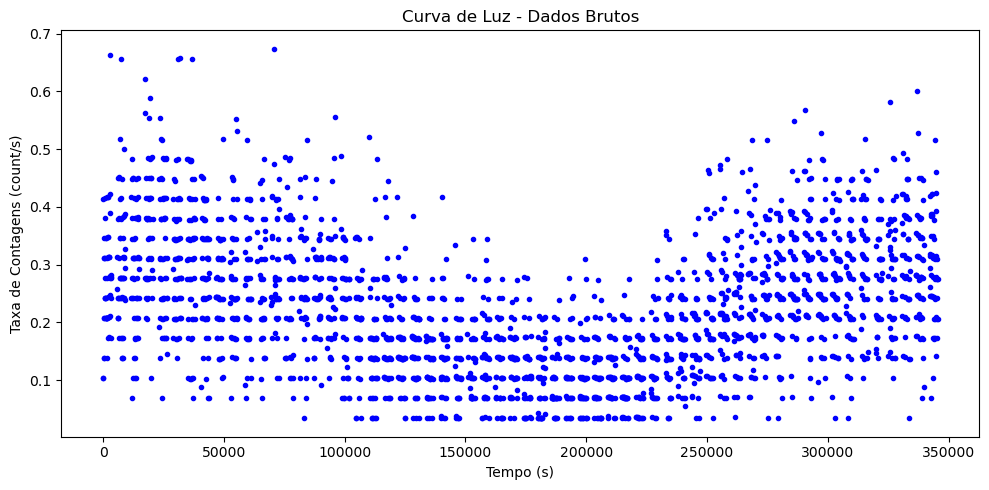

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Definindo as colunas
colunas = ['Index', 'Time', 'Rate', 'Error']

# 2. Lendo os dados (Nota: adicionado o "r" antes de '\s+' para corrigir o SyntaxWarning)
df = pd.read_csv('lc_srcA_3-10_src-corr.dat', sep=r'\s+', names=colunas, comment='#')

# 3. Forçando as colunas a serem tratadas como números (ignora cabeçalhos extras)
df['Time'] = pd.to_numeric(df['Time'], errors='coerce')
df['Rate'] = pd.to_numeric(df['Rate'], errors='coerce')

# 4. Removendo linhas vazias/inválidas e removendo taxas iguais a zero (gaps)
df = df.dropna(subset=['Time', 'Rate'])
df = df[df['Rate'] > 0]

# 5. Criando o plot
plt.figure(figsize=(10, 5))

# Plotando com linestyle='' para exibir apenas os pontos (evita quedas abruptas no gráfico)
plt.plot(df['Time'], df['Rate'], marker='.', linestyle='', color='blue')

# Configurando os eixos
plt.xlabel('Tempo (s)')
plt.ylabel('Taxa de Contagens (count/s)')
plt.title('Curva de Luz - Dados Brutos')

# Mostrando o gráfico
plt.tight_layout()
plt.show()

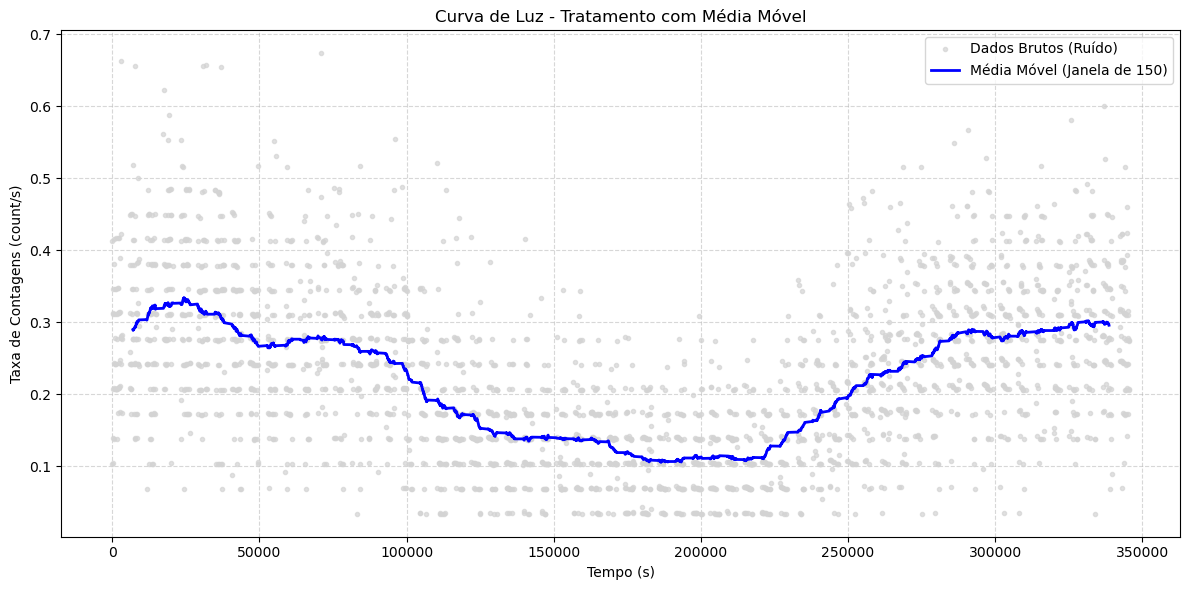

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

colunas = ['Index', 'Time', 'Rate', 'Error']
df = pd.read_csv('lc_srcA_3-10_src-corr.dat', sep=r'\s+', names=colunas, comment='#')

df['Time'] = pd.to_numeric(df['Time'], errors='coerce')
df['Rate'] = pd.to_numeric(df['Rate'], errors='coerce')
df = df.dropna(subset=['Time', 'Rate'])
df = df[df['Rate'] > 0]

tamanho_janela = 150
df['Rate_Smooth'] = df['Rate'].rolling(window=tamanho_janela, center=True).mean()

plt.figure(figsize=(12, 6))

plt.plot(df['Time'], df['Rate'], marker='.', linestyle='', color='lightgray', 
         alpha=0.7, label='Dados Brutos (Ruído)')

plt.plot(df['Time'], df['Rate_Smooth'], color='blue', linewidth=2, 
         label=f'Média Móvel (Janela de {tamanho_janela})')

plt.xlabel('Tempo (s)')
plt.ylabel('Taxa de Contagens (count/s)')
plt.title('Curva de Luz - Tratamento com Média Móvel')
plt.legend() 
plt.grid(True, linestyle='--', alpha=0.5)

# Mostrando o gráfico
plt.tight_layout()
plt.show()

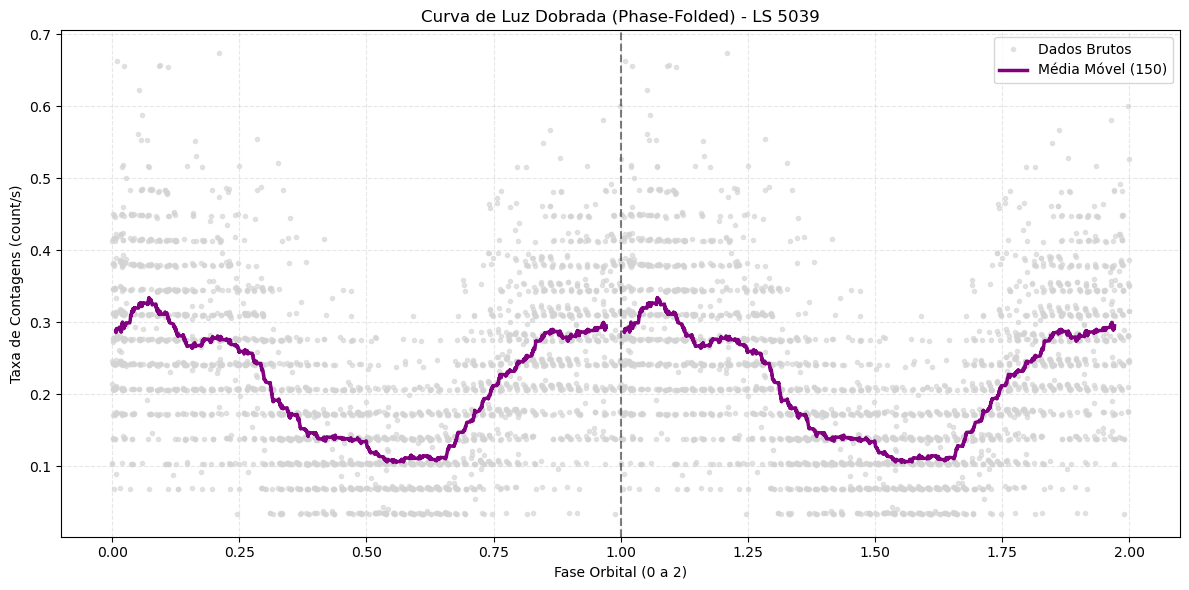

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

colunas = ['Index', 'Time', 'Rate', 'Error']
df = pd.read_csv('lc_srcA_3-10_src-corr.dat', sep=r'\s+', names=colunas, comment='#')

df['Time'] = pd.to_numeric(df['Time'], errors='coerce')
df['Rate'] = pd.to_numeric(df['Rate'], errors='coerce')
df = df.dropna(subset=['Time', 'Rate'])
df = df[df['Rate'] > 0].copy()

periodo_dias = 3.906 
periodo_segundos = periodo_dias * 86400 
df['Phase'] = (df['Time'] / periodo_segundos) % 1.0

df = df.sort_values('Phase')

tamanho_janela = 150
df['Rate_Smooth'] = df['Rate'].rolling(window=tamanho_janela, center=True).mean()

plt.figure(figsize=(12, 6))

plt.plot(df['Phase'], df['Rate'], marker='.', linestyle='', color='lightgray', alpha=0.6, label='Dados Brutos')
plt.plot(df['Phase'], df['Rate_Smooth'], color='purple', linewidth=2.5, label=f'Média Móvel ({tamanho_janela})')

plt.plot(df['Phase'] + 1, df['Rate'], marker='.', linestyle='', color='lightgray', alpha=0.6)
plt.plot(df['Phase'] + 1, df['Rate_Smooth'], color='purple', linewidth=2.5)

plt.xlabel('Fase Orbital (0 a 2)')
plt.ylabel('Taxa de Contagens (count/s)')
plt.title('Curva de Luz Dobrada (Phase-Folded) - LS 5039')
plt.axvline(x=1.0, color='black', linestyle='--', alpha=0.5) # Linha divisória no ciclo 1
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

Melhor período: 3.8449 dias


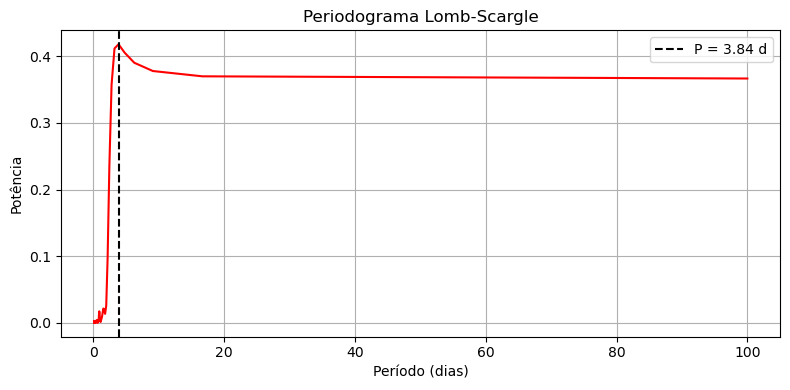

In [13]:
import matplotlib.pyplot as plt
import numpy as np
from astropy.timeseries import LombScargle

_, time, rate, err = np.loadtxt(
    'lc_srcA_3-10_src-corr.dat', unpack=True, skiprows=4
)
mask = (rate > 0) & ~np.isnan(rate)

t_dias = time[mask] / 86400.0
freq, power = LombScargle(t_dias, rate[mask], err[mask]).autopower(
    minimum_frequency=1 / 100.0, maximum_frequency=1 / 0.1
)

periodos = 1 / freq
best_p = periodos[np.argmax(power)]
print(f'Melhor período: {best_p:.4f} dias')


plt.figure(figsize=(8, 4))
plt.plot(periodos, power, 'r-')
plt.axvline(best_p, color='k', ls='--', label=f'P = {best_p:.2f} d')
plt.xlabel('Período (dias)')
plt.ylabel('Potência')
plt.title('Periodograma Lomb-Scargle')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()